<a href="https://colab.research.google.com/github/Bloop15/ML-2025-26/blob/main/MNIST_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
# Import the libraries
import numpy as np
import struct
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [12]:
# Load the dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(f"Training data shape: {x_train.shape}")
print(f"Testing data shape: {x_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


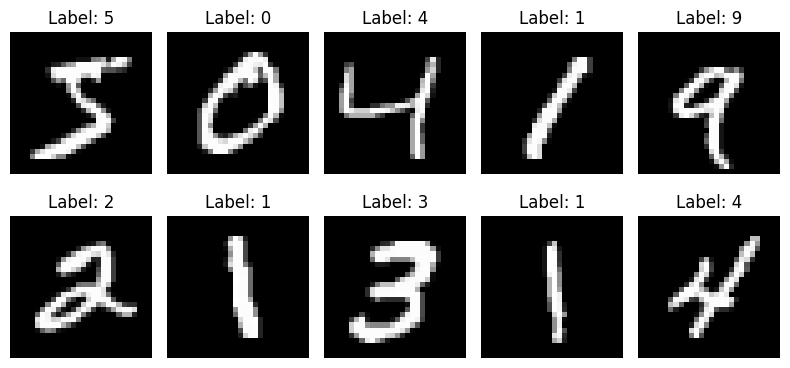

In [13]:
# Visualize the dataset
plt.figure(figsize=(8, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [14]:
# Normalize the Data
# Pixel values range from 0–255; we scale them to 0–1
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

In [15]:
# Convert Labels to One-Hot Encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [16]:
# Build the Model
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [17]:
# Complile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
# Train the model
history = model.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=128,
    verbose=2
)

Epoch 1/10
422/422 - 7s - 15ms/step - accuracy: 0.8305 - loss: 0.5531 - val_accuracy: 0.9537 - val_loss: 0.1590
Epoch 2/10
422/422 - 1s - 3ms/step - accuracy: 0.9257 - loss: 0.2535 - val_accuracy: 0.9672 - val_loss: 0.1170
Epoch 3/10
422/422 - 1s - 3ms/step - accuracy: 0.9422 - loss: 0.1969 - val_accuracy: 0.9728 - val_loss: 0.0947
Epoch 4/10
422/422 - 2s - 4ms/step - accuracy: 0.9515 - loss: 0.1659 - val_accuracy: 0.9748 - val_loss: 0.0853
Epoch 5/10
422/422 - 1s - 3ms/step - accuracy: 0.9562 - loss: 0.1456 - val_accuracy: 0.9733 - val_loss: 0.0835
Epoch 6/10
422/422 - 1s - 2ms/step - accuracy: 0.9597 - loss: 0.1321 - val_accuracy: 0.9792 - val_loss: 0.0763
Epoch 7/10
422/422 - 1s - 2ms/step - accuracy: 0.9647 - loss: 0.1174 - val_accuracy: 0.9793 - val_loss: 0.0745
Epoch 8/10
422/422 - 1s - 3ms/step - accuracy: 0.9659 - loss: 0.1100 - val_accuracy: 0.9792 - val_loss: 0.0715
Epoch 9/10
422/422 - 1s - 3ms/step - accuracy: 0.9686 - loss: 0.1036 - val_accuracy: 0.9798 - val_loss: 0.0670


In [19]:
# Evaluate on test dataset
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\n✅ Test Accuracy: {test_acc * 100:.2f}%")


✅ Test Accuracy: 97.63%


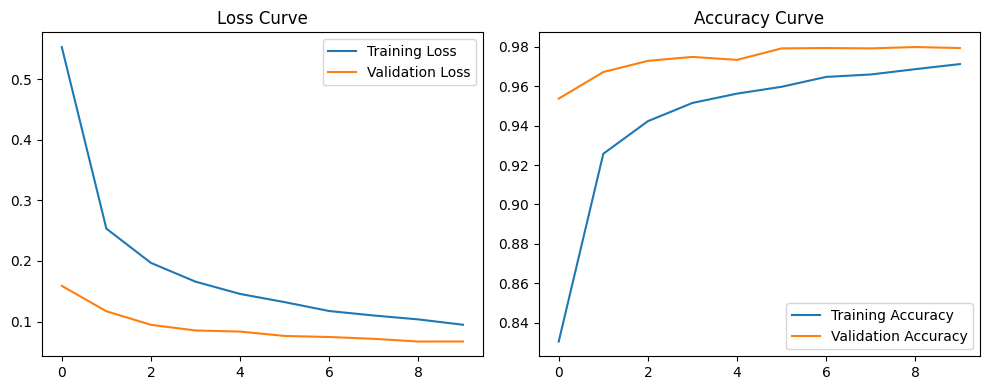

In [20]:
# Plot training curves
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Curve")

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Curve")

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


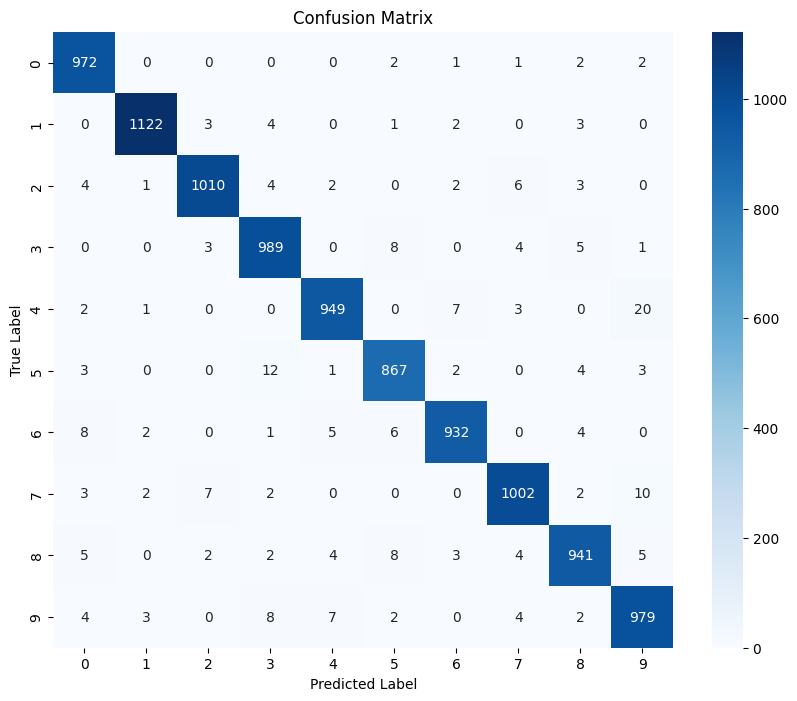

In [24]:
# Confusion Matrix
y_pred = model.predict(x_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true_labels, y_pred_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

Total misclassified images: 237


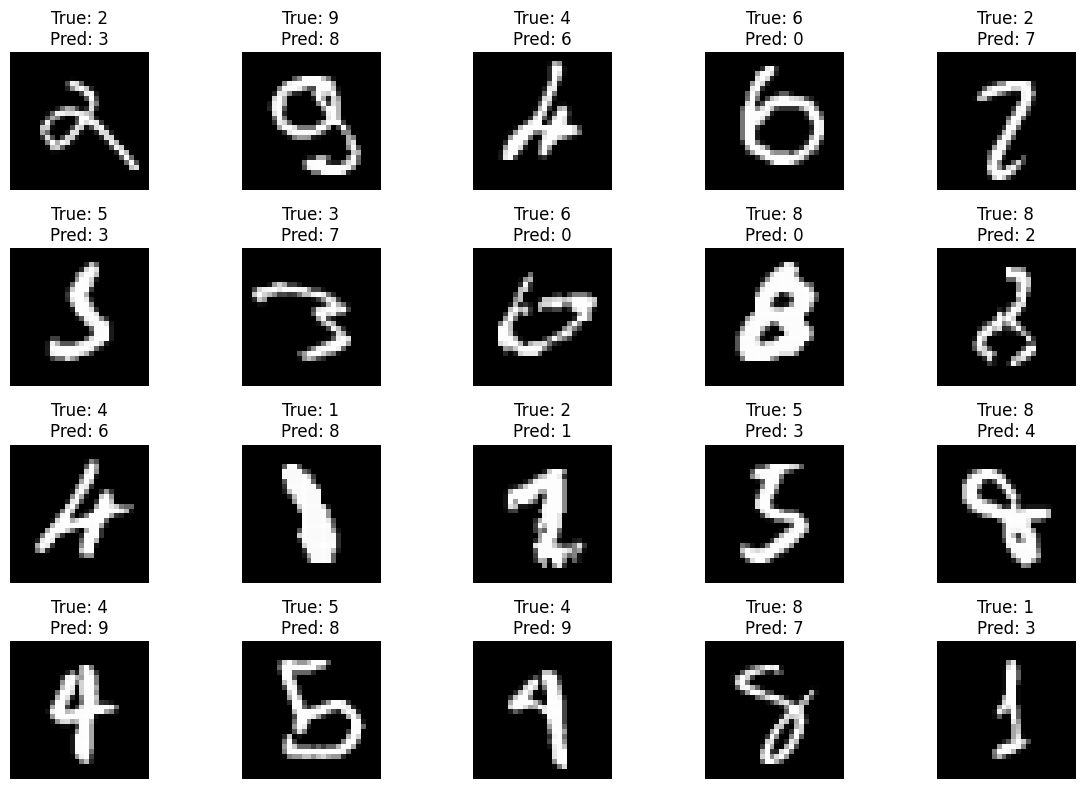

In [25]:
# Find misclassified indices
misclassified_indices = np.where(y_pred_labels != y_true_labels)[0]

print(f"Total misclassified images: {len(misclassified_indices)}")

# Plot first 20 misclassified samples
plt.figure(figsize=(12, 8))
for i, index in enumerate(misclassified_indices[:20]):
    plt.subplot(4, 5, i + 1)
    plt.imshow(x_test[index], cmap='gray')
    plt.title(f"True: {y_true_labels[index]}\nPred: {y_pred_labels[index]}")
    plt.axis('off')
plt.tight_layout()
plt.show()
